In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#K-means is an unsupervised learning algo used for clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [6]:
df=pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
df['Gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [8]:
gender_id={
    'Male':0, 'Female':1
}
df['Gender_id']=df['Gender'].map(gender_id)

In [9]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Gender_id'],
      dtype='str')

In [10]:
X=df[['Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Gender_id']]

In [11]:
scaler=StandardScaler()
X_scale=scaler.fit_transform(X)


In [12]:
import warnings
warnings.filterwarnings('ignore')
error_rate=[]
k_range=range(1,21)
for i in k_range:
    kmeans=KMeans(n_clusters=i)
    kmeans.fit_predict(X_scale)
    error_rate.append(kmeans.inertia_)

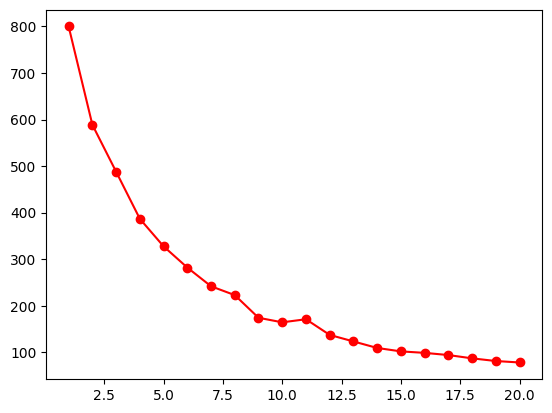

In [13]:
plt.plot(k_range,error_rate,c='red',marker='o')

In [14]:
model=KMeans(n_clusters=5)
clusters=model.fit_predict(X_scale)

In [15]:
show_labels=model.labels_


In [ ]:
#accuracy for clustering
#as accuracy doesnot affect model itself
ss=silhouette_score(X_scale,show_labels)
print(ss)

0.2519263391418845


In [18]:
df['clusters']=clusters
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Gender_id,clusters
0,1,Male,19,15,39,0,2
1,2,Male,21,15,81,0,2
2,3,Female,20,16,6,1,2
3,4,Female,23,16,77,1,2
4,5,Female,31,17,40,1,2
...,...,...,...,...,...,...,...
195,196,Female,35,120,79,1,0
196,197,Female,45,126,28,1,3
197,198,Male,32,126,74,0,0
198,199,Male,32,137,18,0,4


<Axes: xlabel='Age', ylabel='Spending Score (1-100)'>

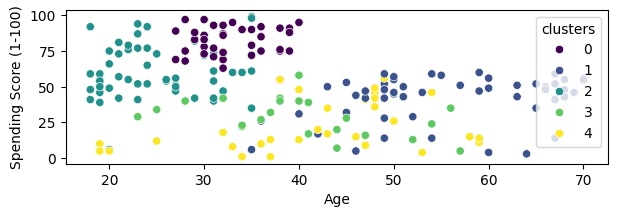

In [22]:
plt.figure(figsize=(7,2))
sns.scatterplot(data=df,x='Age',y='Spending Score (1-100)',hue='clusters',palette='viridis')

In [ ]:
'''
supervised learning
Regression=> for continous data prediction
linear regression
Random forest Regressor

natural language processing we use algo called Naive Bayes, its under regression

classification-> for binary classification/ multi-classification
logistic regression
KNN (K-Nearest Neighbors)

Unsupervised Lerning->for segementation->unlabled data
K-means

Tokens: each word is a token
....
prompt:what is an amimal?-> 5 tokens
Answer:
'''